<a href="https://colab.research.google.com/github/amnawidatalla-blip/sudan-markowitz-portfolio/blob/main/sudan_markowitz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
import yfinance as yf
ticker = "SPY"

In [75]:
prices = yf.download(ticker, start="2019-1-1" , end="2023-3-31")["Close"]
print(prices.head())

/tmp/ipykernel_645/3522392758.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(ticker, start="2019-1-1" , end="2023-3-31")["Close"]
[*********************100%***********************]  1 of 1 completed

Ticker             SPY
Date                  
2019-01-02  223.251556
2019-01-03  217.924149
2019-01-04  225.223663
2019-01-07  226.999496
2019-01-08  229.132233


In [76]:
tickers = ["SPY" , "GLD" , "USO" , "WEAT" , "EZA" , "KSA" , "TLT" , "ITA" , "AFK"]
prices = yf.download(tickers, start="2019-1-1" , end="2023-3-31")["Close"]
print(prices.head())

/tmp/ipykernel_645/3203375510.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start="2019-1-1" , end="2023-3-31")["Close"]
[*********************100%***********************]  9 of 9 completed

Ticker            AFK        EZA         GLD        ITA        KSA  \
Date                                                                 
2019-01-02  15.850013  33.049965  121.330002  80.512115  24.472937   
2019-01-03  15.963399  33.148548  122.430000  78.095116  24.046520   
2019-01-04  16.360258  34.955814  121.440002  80.646629  24.556545   
2019-01-07  16.344061  34.502357  121.860001  81.314690  25.008045   
2019-01-08  16.295467  34.515495  121.529999  82.646103  25.083296   

Ticker             SPY        TLT        USO       WEAT  
Date                                                     
2019-01-02  223.251556  97.169121  78.800003  29.900000  
2019-01-03  217.924149  98.274834  79.599998  30.150000  
2019-01-04  225.223663  97.137299  81.440002  30.299999  
2019-01-07  226.999496  96.850914  82.320000  30.299999  
2019-01-08  229.132233  96.596329  84.000000  30.450001  


In [77]:
returns = prices.pct_change().dropna()
print(returns.head())

Ticker           AFK       EZA       GLD       ITA       KSA       SPY  \
Date                                                                     
2019-01-03  0.007154  0.002983  0.009066 -0.030020 -0.017424 -0.023863   
2019-01-04  0.024861  0.054520 -0.008086  0.032672  0.021210  0.033496   
2019-01-07 -0.000990 -0.012972  0.003458  0.008284  0.018386  0.007885   
2019-01-08 -0.002973  0.000381 -0.002708  0.016374  0.003009  0.009395   
2019-01-09  0.010934  0.025704  0.006418  0.005221  0.008000  0.004673   

Ticker           TLT       USO      WEAT  
Date                                      
2019-01-03  0.011379  0.010152  0.008361  
2019-01-04 -0.011575  0.023116  0.004975  
2019-01-07 -0.002948  0.010805  0.000000  
2019-01-08 -0.002629  0.020408  0.004951  
2019-01-09 -0.001565  0.052381  0.000000  


In [78]:
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252
print(mean_returns)

Ticker
AFK     0.020284
EZA     0.074839
GLD     0.110336
ITA     0.119280
KSA     0.112823
SPY     0.154407
TLT    -0.001505
USO     0.066621
WEAT    0.085668
dtype: float64


In [79]:
import numpy as np
weights = np.ones(9) / 9
port_return = np.dot(weights, mean_returns)
port_risk = np.sqrt(weights. T @ cov_matrix @ weights)
print("return" , port_return)
print("risk" , port_risk)

return 0.08252813690594268
risk 0.161190503087527


In [80]:
random_weights = np.random.random(9)
random_weights = random_weights / random_weights.sum()
print(random_weights)
print("sum" , random_weights.sum())

[0.05984904 0.14815463 0.18037786 0.15251237 0.0627896  0.12901969
 0.09685259 0.14267267 0.02777155]
sum 0.9999999999999999


In [81]:
all_weights = []
all_returns = []
all_risks = []
np.random.seed(42)
for i in range(5000):
    w = np.random.random(9)
    w = w / w.sum()
    r = np.dot(w, mean_returns)
    risk = np.sqrt(w. T @ cov_matrix @ w)
    all_weights.append(w)
    all_returns.append(r)
    all_risks.append(risk)
sharp = np.array(all_returns) / np.array(all_risks)
print("Done! Best Sharp:", sharp.max())

Done! Best Sharp: 0.7899850204287421


In [82]:
best_index = sharp.argmax()

best_weights = all_weights[best_index]
best_return = all_returns[best_index]
best_risk = all_risks[best_index]

print("Return" , best_return)
print("Risk" , best_risk)
print(dict(zip(tickers, best_weights.round(3))))

Return 0.09703232085345215
Risk 0.12282805160127035
{'SPY': np.float64(0.012), 'GLD': np.float64(0.007), 'USO': np.float64(0.236), 'WEAT': np.float64(0.041), 'EZA': np.float64(0.142), 'KSA': np.float64(0.185), 'TLT': np.float64(0.13), 'ITA': np.float64(0.008), 'AFK': np.float64(0.239)}


In [83]:
war_prices = yf.download(tickers , start="2023-04-15" , end="2026-10-2")["Close"]

war_returns = war_prices.pct_change().dropna()
war_mean = war_returns.mean()* 252
war_cov = war_returns.cov()* 252

print(war_prices.shape)

/tmp/ipykernel_645/3440417484.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  war_prices = yf.download(tickers , start="2023-04-15" , end="2026-10-2")["Close"]
[*********************100%***********************]  9 of 9 completed

(869, 9)


In [84]:
print(dict(zip(returns.columns, best_weights.round(3))))

best_war_return = np.dot(best_weights, war_mean)
best_war_risk = np.sqrt(best_weights.T @ war_cov @ best_weights)

equal_weights = np.ones(9) / 9
equal_war_return = np.dot(equal_weights, war_mean)
equal_war_risk = np.sqrt(equal_weights.T @ war_cov @ equal_weights)

print("Optimal -> Return:", best_war_return, "Risk:", best_war_risk)
print("Equal   -> Return:", equal_war_return, "Risk:", equal_war_risk)

{'AFK': np.float64(0.012), 'EZA': np.float64(0.007), 'GLD': np.float64(0.236), 'ITA': np.float64(0.041), 'KSA': np.float64(0.142), 'SPY': np.float64(0.185), 'TLT': np.float64(0.13), 'USO': np.float64(0.008), 'WEAT': np.float64(0.239)}
Optimal -> Return: 0.08501402050890564 Risk: 0.10234041373334157
Equal   -> Return: 0.13378274387481529 Risk: 0.11445617250619256


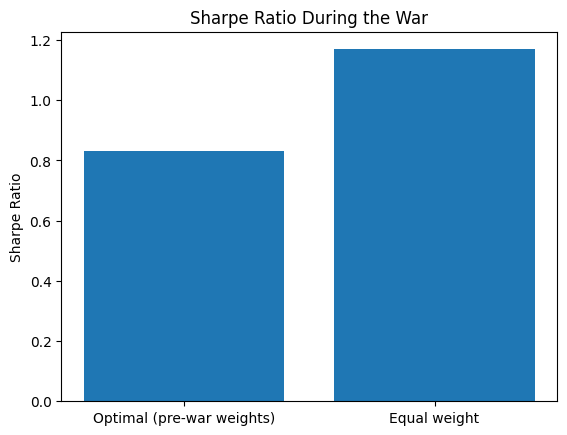

In [85]:
import matplotlib.pyplot as plt

sharpe_values = [best_war_return / best_war_risk, equal_war_return / equal_war_risk]
names = ["Optimal (pre-war weights)", "Equal weight"]

plt.bar(names, sharpe_values)
plt.title("Sharpe Ratio During the War")
plt.ylabel("Sharpe Ratio")
plt.show()